# Selection criteria for the HMM hits

Working notebook for deciding when an hmmsearch hit counts as an ortholog of the arabinose cluster genes.

Input: the unfiltered hmmsearch `.tblout` files from `05_search_genomes.py` (no cutoff applied, hits go down to
HMMER's default E = 10), for both genome sets:
- `results/raw/Streptomycetae/`
- `results/raw/Actinobacteria/`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
HMM_DIR = PROJECT_DIR / "hmm_search"
RAW_DIRS = {
    "Streptomycetae": HMM_DIR / "results" / "raw" / "Streptomycetae",
    "Actinobacteria": HMM_DIR / "results" / "raw" / "Actinobacteria",
}

# tblout columns (HMMER 3 --tblout); the last one, the description, can contain spaces
TBLOUT_COLS = [
    "target", "target_acc", "model", "model_acc",
    "evalue", "bitscore", "bias",
    "best_dom_evalue", "best_dom_bitscore", "best_dom_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
    "description",
]
FLOAT_COLS = ["evalue", "bitscore", "bias", "best_dom_evalue", "best_dom_bitscore", "best_dom_bias", "exp"]

## Lookup table: RBH query names -> HMM model names

In [2]:
# RBH query name (reciprocal_hits.tsv qseqid = FASTA header in RBH/data/arabinose_clusters/)
# -> hmmsearch model name (as in the .tblout files), so RBH and HMM hits share one identifier
RBH_TO_MODEL = {
    "SCO2401": "SCO2401",
    "SCO2402": "SCO2402",
    "SCO2403": "SCO2403",
    "SCO2407": "SCO2407",
    "SCO2439": "SCO2439",
    "SCO2440": "SCO2440",
    "vnz_33170-lacI": "lacI-AraR",
    "vnz_33175-araB": "AraB",
    "vnz_33180-araA": "AraA",
    "vnz_33185-araD": "AraD",
}

## 1. Load the hits

In [3]:
def read_tblout(path):
    """Returns (hits table, finished): finished is False when the '# [ok]' line is missing."""
    rows = []
    finished = False
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                if line.startswith("# [ok]"):
                    finished = True
                continue
            rows.append(line.rstrip("\n").split(maxsplit=len(TBLOUT_COLS) - 1))
    return pd.DataFrame(rows, columns=TBLOUT_COLS), finished


tables = []
for genome_set, raw_dir in RAW_DIRS.items():
    for path in sorted(raw_dir.glob("*.tblout")):
        df, finished = read_tblout(path)
        if not finished:
            print("WARNING: search did not finish:", path.name)
        df["genome_set"] = genome_set
        df["tblout"] = path.stem
        tables.append(df)

hmm_hits = pd.concat(tables, ignore_index=True)
hmm_hits[FLOAT_COLS] = hmm_hits[FLOAT_COLS].astype(float)

# 'Genome|LOCUS_TAG|description|accession'; brackets dropped so '[Kitasatospora]_papulosa' matches RBH
hmm_hits["genome"] = hmm_hits.target.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
hmm_hits["locus_tag"] = hmm_hits.target.str.split("|").str[1]
# Conserved- / Conserved_ prefix of the model names dropped: every model has it
hmm_hits["model"] = hmm_hits.model.str.replace(r"^Conserved[-_]", "", regex=True)
hmm_hits["gene"] = hmm_hits.model
# rank of each hit within its (genome, model): 1 = best-scoring protein
hmm_hits = hmm_hits.sort_values("bitscore", ascending=False)
hmm_hits["rank"] = hmm_hits.groupby(["genome_set", "genome", "model"]).cumcount() + 1

print(f"{len(hmm_hits)} hits from {hmm_hits.tblout.nunique()} genomes")
hmm_hits.groupby(["genome_set", "gene"]).agg(genomes=("genome", "nunique"), hits=("target", "size"))

34407 hits from 459 genomes


genomes  hits
genome_set     gene                    
Actinobacteria AraA           123   151
               AraB           245  1044
               AraD           192   398
               SCO2401        227   935
               SCO2402        248  3983
               SCO2403         73   104
               SCO2407        187   272
               SCO2439        156   387
               SCO2440        232  1951
               lacI-AraR      236  3988
Streptomycetae AraA            64    78
               AraB           207  1316
               AraD           207   623
               SCO2401        196  1115
               SCO2402        207  6318
               SCO2403        155   374
               SCO2407        199   451
               SCO2439        197   559
               SCO2440        207  3520
               lacI-AraR      207  6840

In [4]:
hmm_hits

,target,target_acc,model,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,...,dom,rep,inc,description,genome_set,tblout,genome,locus_tag,gene,rank
19702,Streptomyces_venezuelae|vnz_RS33510|ribulokina...,-,AraB,-,0.00,1053.2,4.7,0.000,1052.9,4.7,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_strain_NRRL_B-65442,Streptomyces_venezuelae,vnz_RS33510,AraB,1
19618,Streptomyces_venezuelae_ATCC_10712|DEJ43_RS336...,-,AraB,-,0.00,1053.2,4.7,0.000,1052.9,4.7,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_ATCC_10712_protein,Streptomyces_venezuelae_ATCC_10712,DEJ43_RS33660,AraB,1
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,AraB,-,0.00,1043.9,8.7,0.000,1043.8,8.7,...,1,1,1,-,Actinobacteria,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1
18774,Streptomyces_tanashiensis|LDH80_RS06025|ribulo...,-,AraB,-,0.00,1043.2,5.2,0.000,1042.9,5.2,...,1,1,1,-,Streptomycetae,Streptomyces_tanashiensis_protein,Streptomyces_tanashiensis,LDH80_RS06025,AraB,1
8144,Streptomyces_gardneri|H4W23_RS03215|ribulokina...,-,AraB,-,0.00,1042.9,5.6,0.000,1042.6,5.6,...,1,1,1,-,Streptomycetae,Streptomyces_gardneri_protein,Streptomyces_gardneri,H4W23_RS03215,AraB,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18638,Streptomyces_stoeckheimensis|ACE1OC_RS37635|xy...,-,AraB,-,1.60,5.9,11.1,0.150,9.3,0.2,...,4,4,0,-,Streptomycetae,Streptomyces_stoeckheimensis_protein,Streptomyces_stoeckheimensis,ACE1OC_RS37635,AraB,5
28998,Mycobacterium_tuberculosis_H37Rv|Rv2181|alpha-...,-,SCO2402,-,1.20,5.9,6.3,1.900,5.3,0.6,...,3,3,0,mannoside mannosyltransferase|NP_216697.1,Actinobacteria,Mycobacterium_tuberculosis_H37Rv,Mycobacterium_tuberculosis_H37Rv,Rv2181,SCO2402,14
30139,Paeniglutamicibacter_sp._Y32M11|KUF55_RS08720|...,-,AraB,-,0.74,5.8,6.8,0.068,9.3,1.6,...,2,2,0,cytochrome|WP_132363896.1,Actinobacteria,Paeniglutamicibacter_sp._Y32M11,Paeniglutamicibacter_sp._Y32M11,KUF55_RS08720,AraB,3
5426,Streptomyces_clavuligerus|CRV15_RS31785|hypoth...,-,SCO2407,-,3.30,5.3,7.4,3.800,5.0,6.9,...,1,1,0,protein|WP_009999291.1,Streptomycetae,Streptomyces_clavuligerus_protein,Streptomyces_clavuligerus,CRV15_RS31785,SCO2407,4


## 2. Add the "true" hist from blast 

In [5]:
RBH_HITS = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"
MATCH_COLS = ["genome_set", "genome", "locus_tag", "gene"]

# reciprocal best hits, only run against the Streptomycetae genomes; SCO and VNZ queries both kept,
# renamed to their HMM model names (original query name kept in rbh_query)
rbh_hits = pd.read_csv(RBH_HITS, sep="\t")
rbh_hits["rbh_query"] = rbh_hits.qseqid
rbh_hits["qseqid"] = rbh_hits.qseqid.map(RBH_TO_MODEL)
unmapped = rbh_hits.loc[rbh_hits.qseqid.isna(), "rbh_query"].unique()
if len(unmapped):
    print("WARNING: RBH queries missing from RBH_TO_MODEL:", ", ".join(unmapped))
rbh_hits["genome_set"] = "Streptomycetae"
rbh_hits["locus_tag"] = rbh_hits.sseqid.str.split("|").str[1]
rbh_hits["gene"] = rbh_hits.qseqid
# drop RBH queries whose model is not in the current hmmsearch results
rbh_hits = rbh_hits[rbh_hits.gene.isin(hmm_hits.gene.unique())]

rbh_keys = pd.MultiIndex.from_frame(rbh_hits[MATCH_COLS])
hmm_keys = pd.MultiIndex.from_frame(hmm_hits[MATCH_COLS])
hmm_hits["is_rbh"] = hmm_keys.isin(rbh_keys)

# RBH hits that hmmsearch did not report at all
missed = rbh_hits[~rbh_keys.isin(hmm_keys)]
print(f"{hmm_hits.is_rbh.sum()} of {len(rbh_hits)} RBH hits found among the HMM hits")
if len(missed):
    print(missed.groupby("gene").size().to_string())

# rank of the RBH hits within their (genome, model)
hmm_hits[hmm_hits.is_rbh].groupby("gene")["rank"].value_counts().unstack(fill_value=0)

848 of 848 RBH hits found among the HMM hits


rank,1,2,3
gene,,,
AraA,32,2,1
AraB,32,3,1
AraD,24,2,1
SCO2401,130,0,0
SCO2402,94,0,0
SCO2403,129,1,0
SCO2407,95,0,0
SCO2439,125,0,0
SCO2440,132,1,0


In [6]:
rbh_hits

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,...,full_sseq,query_file,ref_group,true_ref_id,genome,rev_bitscore,rbh_query,genome_set,locus_tag,gene
0,SCO2401,Streptomyces_coelicolor_A3(2)|SCO2401|dehydrat...,99.7,388,388,388,1,388,1,388,...,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicolor_A3(2),794.0,SCO2401,Streptomycetae,SCO2401,SCO2401
1,SCO2401,Streptomyces_violaceoruber|R2E43_RS26250|mande...,99.7,388,388,388,1,388,1,388,...,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_violaceoruber,794.0,SCO2401,Streptomycetae,R2E43_RS26250,SCO2401
2,SCO2401,Streptomyces_anthocyanicus|OIE72_RS26120|mande...,99.5,388,388,388,1,388,1,388,...,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_anthocyanicus,793.0,SCO2401,Streptomycetae,OIE72_RS26120,SCO2401
3,SCO2401,Streptomyces_rubrogriseus|Sru02f_RS06985|mande...,99.0,388,388,388,1,388,1,388,...,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_rubrogriseus,790.0,SCO2401,Streptomycetae,Sru02f_RS06985,SCO2401
4,SCO2401,Streptomyces_coelicoflavus|OHA99_RS25815|mande...,98.7,388,388,388,1,388,1,388,...,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicoflavus,787.0,SCO2401,Streptomycetae,OHA99_RS25815,SCO2401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,AraD,Streptomyces_canus|OHT68_RS00520|L-ribulose-5-...,77.5,236,237,241,1,235,1,236,...,MTAHVRDGLRQEVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,371.0,vnz_33185-araD,Streptomycetae,OHT68_RS00520,AraD
844,AraD,Streptomyces_cynarae|N8I84_RS40475|L-ribulose-...,77.9,235,237,240,1,234,1,235,...,MTTAVPESLRQEVLEANLAIPQVGLATLTWGNVSGVDRKSGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_cynarae,370.0,vnz_33185-araD,Streptomycetae,N8I84_RS40475,AraD
845,AraD,Streptomyces_canus|OHT68_RS02545|L-ribulose-5-...,77.4,235,237,241,1,234,1,235,...,MTTTVPESLRREVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,370.0,vnz_33185-araD,Streptomycetae,OHT68_RS02545,AraD
846,AraD,Streptomyces_prunicolor|OG588_RS46515|L-ribulo...,77.6,237,237,239,1,236,1,237,...,MTARVRDGLRQEVLDANLTIPRVGLATLTWGNVSGVDRAAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_prunicolor,368.0,vnz_33185-araD,Streptomycetae,OG588_RS46515,AraD


In [7]:
# top RBH hit (highest bitscore) for every (query gene, genome)
rbh_top = (
    rbh_hits.sort_values("bitscore", ascending=False)
    .groupby(["qseqid", "genome"])
    .head(1)
    .rename(columns={"locus_tag": "rbh_locus_tag", "sseqid": "rbh_hit", "pident": "rbh_pident",
                     "evalue": "rbh_evalue", "bitscore": "rbh_bitscore"})
)

# top HMM hit for every (model, genome) in the Streptomycetae set
hmm_top = (
    hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 1)]
    .rename(columns={"locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore"})
)

benchmark = rbh_top[["qseqid", "genome", "rbh_locus_tag", "rbh_hit", "rbh_pident", "rbh_evalue", "rbh_bitscore"]].merge(
    hmm_top[["gene", "genome", "model", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "is_rbh"]],
    how="left", left_on=["qseqid", "genome"], right_on=["gene", "genome"],
).drop(columns="gene")

# a genome can have more than one RBH hit per gene (paralogs, e.g. S. zaomyceticus SCO2440):
# the pair agrees when the top HMM hit is any of its RBH hits, not only the top one
agrees = benchmark.is_rbh.fillna(False).astype(bool)
not_agreement_rbh_hmm_table = benchmark[~agrees].drop(columns="is_rbh").reset_index(drop=True)
agree_pairs = benchmark.loc[agrees, ["qseqid", "genome"]]

strep_hits = hmm_hits[hmm_hits.genome_set == "Streptomycetae"].rename(columns={"gene": "qseqid"})

# true hits: every RBH-confirmed HMM hit of the agreeing pairs, so a pair with 2 RBH hits gives 2 rows
agreement_rbh_hmm_table = (
    strep_hits[strep_hits.is_rbh]
    .merge(agree_pairs, on=["qseqid", "genome"])
    .rename(columns={"locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore", "rank": "hmm_rank"})
    [["qseqid", "genome", "model", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "hmm_rank"]]
    .reset_index(drop=True)
)

# second-best: the best HMM hit that is not an RBH hit (rank 2 can itself be an RBH paralog),
# with the gap measured from the lowest-scoring true hit of the pair
best_non_rbh = (
    strep_hits[~strep_hits.is_rbh]
    .sort_values("bitscore", ascending=False)
    .groupby(["qseqid", "genome"])
    .head(1)
    .rename(columns={"locus_tag": "second_locus_tag", "target": "second_hit",
                     "evalue": "second_evalue", "bitscore": "second_bitscore", "rank": "second_rank"})
)
lowest_true_per_pair = agreement_rbh_hmm_table.loc[
    agreement_rbh_hmm_table.groupby(["qseqid", "genome"]).hmm_bitscore.idxmin(),
    ["qseqid", "genome", "model", "hmm_locus_tag", "hmm_bitscore"],
]
second_best_hits = lowest_true_per_pair.merge(
    best_non_rbh[["qseqid", "genome", "second_locus_tag", "second_hit", "second_evalue", "second_bitscore", "second_rank"]],
    on=["qseqid", "genome"],
).reset_index(drop=True)
second_best_hits["bitscore_gap"] = second_best_hits.hmm_bitscore - second_best_hits.second_bitscore

print(f"{len(agree_pairs)} pairs agree ({len(agreement_rbh_hmm_table)} true hits), "
      f"{len(not_agreement_rbh_hmm_table)} do not agree")
print(f"{len(second_best_hits)} agreeing pairs have a non-RBH HMM hit")
pd.DataFrame({
    "agree": agree_pairs.groupby("qseqid").size(),
    "true_hits": agreement_rbh_hmm_table.groupby("qseqid").size(),
    "not_agree": not_agreement_rbh_hmm_table.groupby("qseqid").size(),
}).fillna(0).astype(int)

836 pairs agree (848 true hits), 0 do not agree
801 agreeing pairs have a non-RBH HMM hit


,agree,true_hits,not_agree
qseqid,,,
AraA,32,35,0
AraB,32,36,0
AraD,24,27,0
SCO2401,130,130,0
SCO2402,94,94,0
SCO2403,129,130,0
SCO2407,95,95,0
SCO2439,125,125,0
SCO2440,132,133,0


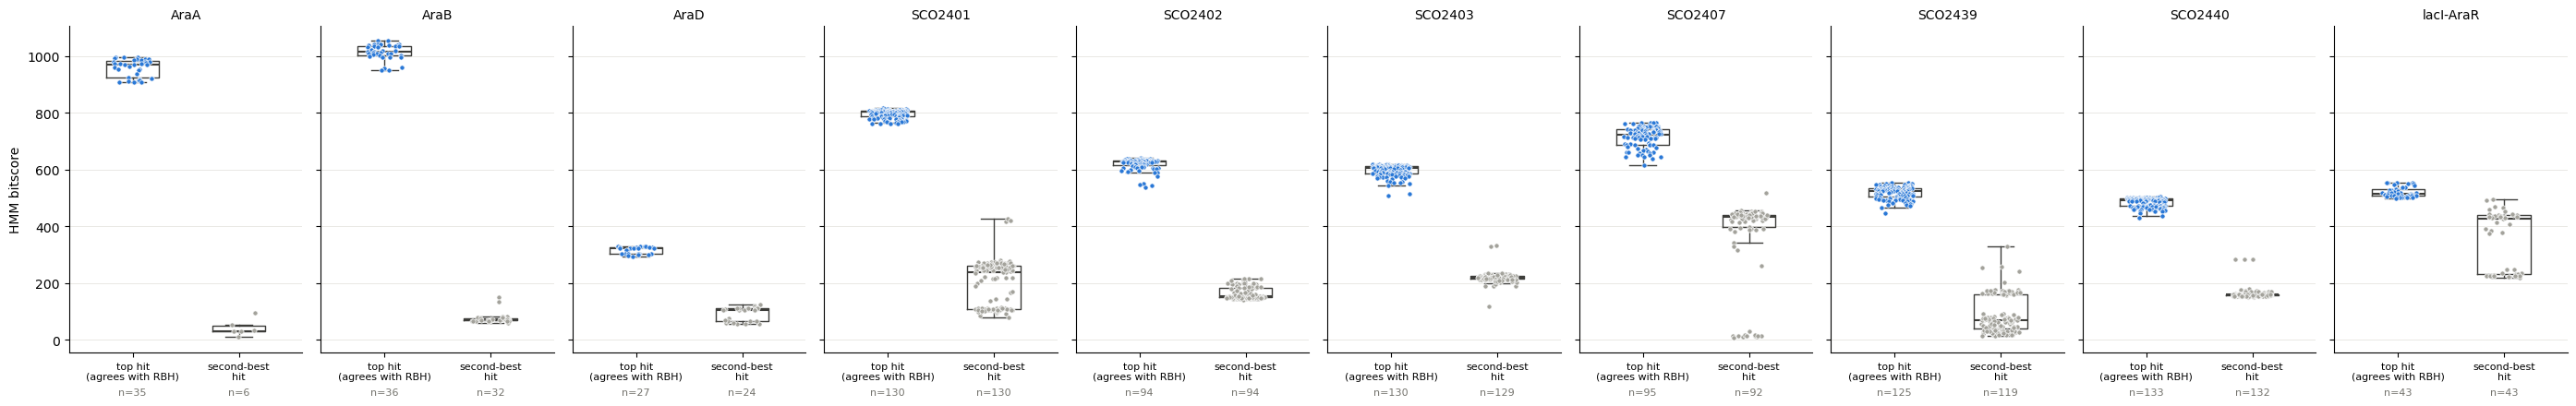

In [8]:
C_TOP = "#2a78d6"     # top HMM hit = RBH ortholog
C_SECOND = "#a3a29b"  # second-best HMM hit

genes = sorted(agreement_rbh_hmm_table.qseqid.unique())
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(genes), figsize=(2.8 * len(genes), 4.5), sharey=True)

for ax, gene in zip(axes, genes):
    groups = [
        ("top hit\n(agrees with RBH)", agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.qseqid == gene, "hmm_bitscore"], C_TOP),
        ("second-best\nhit", second_best_hits.loc[second_best_hits.qseqid == gene, "second_bitscore"], C_SECOND),
    ]
    for x, (label, values, color) in enumerate(groups):
        ax.boxplot(values, positions=[x], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        ax.scatter(x + rng.uniform(-0.18, 0.18, len(values)), values, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
        ax.text(x, -0.13, f"n={len(values)}", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="#73726c")
    ax.set_xticks([0, 1], [label for label, _, _ in groups], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.qseqid == gene, "model"].iloc[0], fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("HMM bitscore")
fig.tight_layout()
plt.show()

Check what is the second best hit in the SCO2440

In [9]:
second_best_hits.loc[second_best_hits.model == "SCO2403"].sort_values("bitscore_gap", ascending=True).head(10)

,qseqid,genome,model,hmm_locus_tag,hmm_bitscore,second_locus_tag,second_hit,second_evalue,second_bitscore,second_rank,bitscore_gap
304,SCO2403,Streptomyces_boninensis,SCO2403,ACNNMR_RS23280,575.1,ACNNMR_RS28385,Streptomyces_boninensis|ACNNMR_RS28385|U32,1.300000e-99,332.4,2,242.7
401,SCO2403,Streptomyces_spinosirectus,SCO2403,LXH13_RS12985,607.1,LXH13_RS38115,Streptomyces_spinosirectus|LXH13_RS38115|U32,9.000000e-99,329.6,2,277.5
391,SCO2403,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SCO2403,SRIM_RS05850,515.2,SRIM_RS05840,Streptomyces_rimosus_subsp._rimosus_ATCC_10970...,3.900000e-61,206.0,2,309.2
352,SCO2403,Streptomyces_inhibens,SCO2403,KI385_RS01675,552.2,KI385_RS01665,Streptomyces_inhibens|KI385_RS01665|mandelate,1.100000e-63,214.4,2,337.8
380,SCO2403,Streptomyces_phytohabitans,SCO2403,ABXR15_RS20360,560.6,ABXR15_RS20350,Streptomyces_phytohabitans|ABXR15_RS20350|mand...,1.300000e-65,220.0,2,340.6
400,SCO2403,Streptomyces_spectabilis,SCO2403,CP982_RS05995,554.1,CP982_RS05985,Streptomyces_spectabilis|CP982_RS05985|mandelate,8.300000e-63,211.4,2,342.7
357,SCO2403,Streptomyces_laculatispora,SCO2403,P8A22_RS05335,577.0,P8A22_RS05325,Streptomyces_laculatispora|P8A22_RS05325|mande...,1.200000e-68,230.5,2,346.5
302,SCO2403,Streptomyces_bathyalis,SCO2403,G4Z16_RS24420,573.7,G4Z16_RS24430,Streptomyces_bathyalis|G4Z16_RS24430|mandelate,4.900000e-67,225.0,2,348.7
344,SCO2403,Streptomyces_halstedii,SCO2403,OG923_RS23900,574.4,OG923_RS23910,Streptomyces_halstedii|OG923_RS23910|mandelate,1.500000e-66,223.5,2,350.9
404,SCO2403,Streptomyces_tubbatahanensis,SCO2403,MMF93_RS06280,568.4,MMF93_RS06290,Streptomyces_tubbatahanensis|MMF93_RS06290|man...,1.700000e-64,216.7,2,351.7


In [10]:
# lowest bitscore of the RBH-confirmed true hits per model; every RBH copy in a genome counts
# (e.g. the second S. zaomyceticus SCO2440 copy, OG567_RS33900)
lowest_true_hit = (
    agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.groupby("model").hmm_bitscore.idxmin()]
    [["model", "qseqid", "genome", "hmm_locus_tag", "hmm_bitscore"]]
    .set_index("model")
)
lowest_true_hit

,qseqid,genome,hmm_locus_tag,hmm_bitscore
model,,,,
AraA,AraA,Streptomyces_cynarae,N8I84_RS40470,907.5
AraB,AraB,Streptomyces_griseofuscus,HEP81_RS01890,951.4
AraD,AraD,Streptomyces_camelliae,O1G22_RS26940,294.4
SCO2401,SCO2401,Streptomyces_xiamenensis,SXIM_RS06610,760.6
SCO2402,SCO2402,Streptomyces_xinghaiensis_S187,SXIN_RS22475,536.6
SCO2403,SCO2403,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30805,509.1
SCO2407,SCO2407,Streptomyces_bathyalis,G4Z16_RS02255,617.0
SCO2439,SCO2439,Streptomyces_liangshanensis,HA039_RS04615,446.7
SCO2440,SCO2440,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30795,430.1


In [11]:
# highest bitscore of the second-best (best non-RBH) hits per model
highest_second_best = (
    second_best_hits.loc[second_best_hits.groupby("model").second_bitscore.idxmax()]
    [["model", "qseqid", "genome", "second_locus_tag", "second_bitscore"]]
    .set_index("model")
)
highest_second_best

,qseqid,genome,second_locus_tag,second_bitscore
model,,,,
AraA,AraA,Streptomyces_erythrochromogenes,OHA91_RS05455,96.5
AraB,AraB,Streptomyces_camelliae,O1G22_RS41040,149.9
AraD,AraD,Streptomyces_canus,OHT68_RS43620,124.4
SCO2401,SCO2401,Streptomyces_poriferorum,P8A21_RS06230,425.6
SCO2402,SCO2402,Streptomyces_hygroscopicus_subsp._hygroscopicus,V8J11_RS38770,216.9
SCO2403,SCO2403,Streptomyces_boninensis,ACNNMR_RS28385,332.4
SCO2407,SCO2407,Streptomyces_boninensis,ACNNMR_RS12475,518.1
SCO2439,SCO2439,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS07985,328.8
SCO2440,SCO2440,Streptomyces_rapamycinicus_NRRL_5491,LIV37_RS42690,285.1


In [12]:
THRESHOLD_FRACTION = 0.5

thresholds = pd.DataFrame({
    "highest_second_best": highest_second_best.second_bitscore,
    "lowest_true_hit": lowest_true_hit.hmm_bitscore,
})
thresholds["gap"] = thresholds.lowest_true_hit - thresholds.highest_second_best
thresholds["threshold"] = thresholds.highest_second_best + THRESHOLD_FRACTION * thresholds.gap
thresholds.round(1)

,highest_second_best,lowest_true_hit,gap,threshold
model,,,,
AraA,96.5,907.5,811.0,502.0
AraB,149.9,951.4,801.5,550.6
AraD,124.4,294.4,170.0,209.4
SCO2401,425.6,760.6,335.0,593.1
SCO2402,216.9,536.6,319.7,376.8
SCO2403,332.4,509.1,176.7,420.8
SCO2407,518.1,617.0,98.9,567.6
SCO2439,328.8,446.7,117.9,387.8
SCO2440,285.1,430.1,145.0,357.6


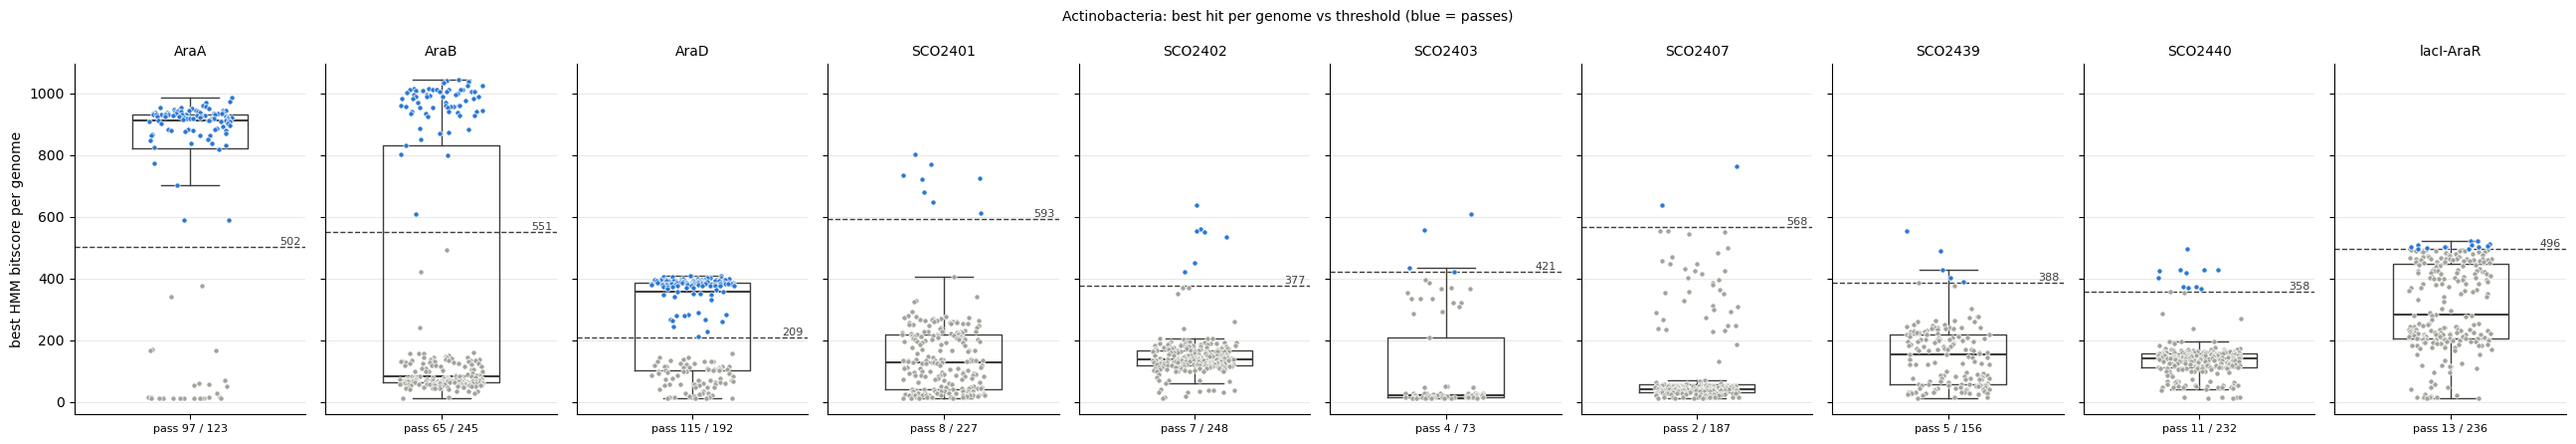

In [13]:
# best hit per (genome, model) in the Actinobacteria set, against the per-model threshold
actino_top = hmm_hits[(hmm_hits.genome_set == "Actinobacteria") & (hmm_hits["rank"] == 1)].copy()
actino_top["threshold"] = actino_top.model.map(thresholds.threshold)
actino_top = actino_top[actino_top.threshold.notna()]  # SCO2408 has no threshold
actino_top["passes"] = actino_top.bitscore >= actino_top.threshold

C_PASS = "#2a78d6"
C_FAIL = "#a3a29b"

models = sorted(thresholds.index, key=lambda m: m[-7:])  # by gene, not by the "-" / "_" in the name
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.6 * len(models), 4.5), sharey=True)

for ax, model in zip(axes, models):
    sub = actino_top[actino_top.model == model]
    ax.boxplot(sub.bitscore, positions=[0], widths=0.5, showfliers=False,
               medianprops={"color": "#3d3d3a", "linewidth": 1.5},
               boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
    for passes, color in [(False, C_FAIL), (True, C_PASS)]:
        y = sub.loc[sub.passes == passes, "bitscore"]
        ax.scatter(rng.uniform(-0.18, 0.18, len(y)), y, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(0.48, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_xticks([0], [f"pass {sub.passes.sum()} / {len(sub)}"], fontsize=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("best HMM bitscore per genome")
fig.suptitle("Actinobacteria: best hit per genome vs threshold (blue = passes)", fontsize=10)
fig.tight_layout()
plt.show()

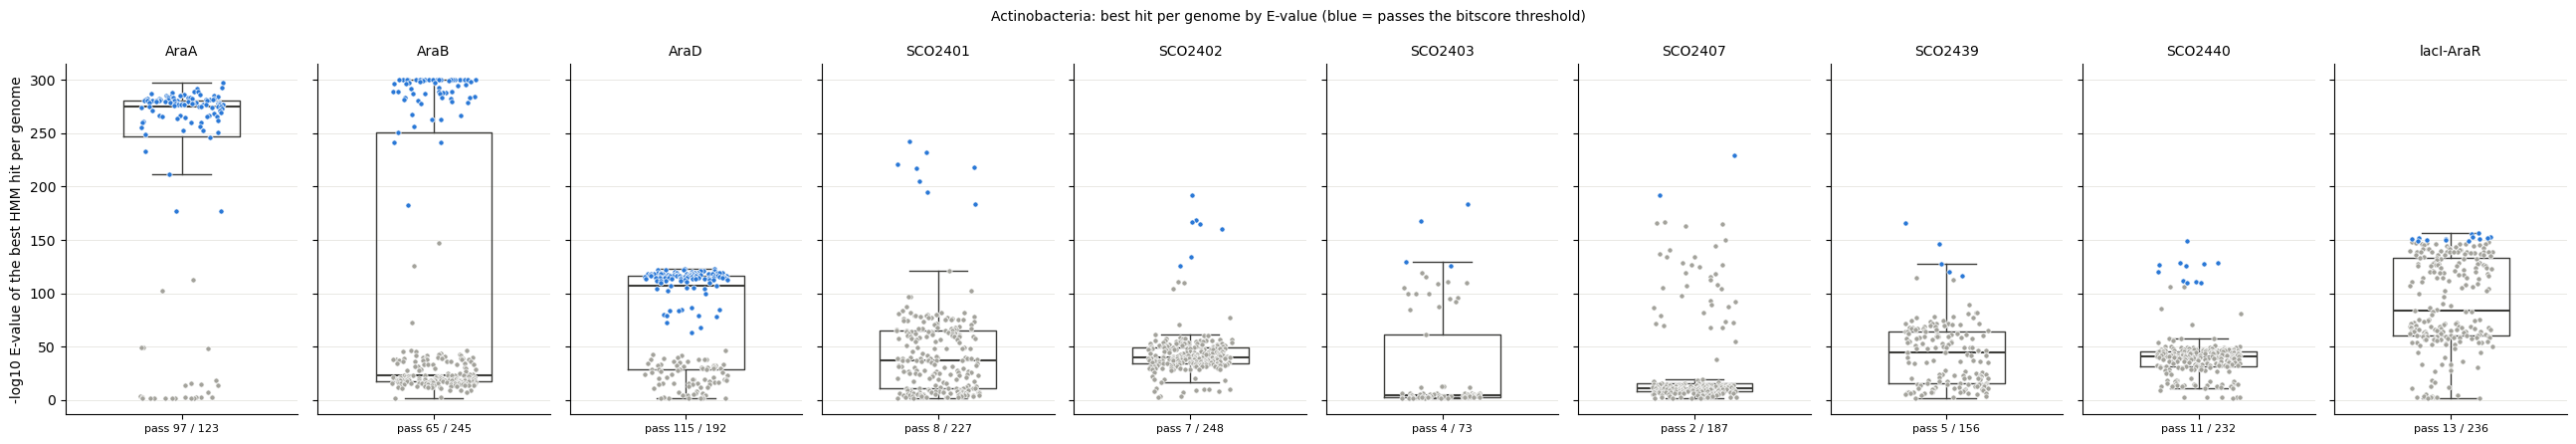

In [14]:
# same best hit per (genome, model) as above, plotted by E-value; blue = passes the bitscore threshold
# (no threshold line: the E-value also depends on each genome's size, so it has no single cutoff)
MIN_EVALUE = 1e-300  # HMMER reports E = 0 below this; those hits are drawn at the floor (300)

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.6 * len(models), 4.5), sharey=True)

for ax, model in zip(axes, models):
    sub = actino_top[actino_top.model == model]
    # -log10 so the boxes are computed on the log scale and stronger hits sit higher, as with bitscores
    log_e = -np.log10(sub.evalue.clip(lower=MIN_EVALUE))
    ax.boxplot(log_e, positions=[0], widths=0.5, showfliers=False,
               medianprops={"color": "#3d3d3a", "linewidth": 1.5},
               boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
    for passes, color in [(False, C_FAIL), (True, C_PASS)]:
        y = log_e[sub.passes == passes]
        ax.scatter(rng.uniform(-0.18, 0.18, len(y)), y, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    ax.set_xticks([0], [f"pass {sub.passes.sum()} / {len(sub)}"], fontsize=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("-log10 E-value of the best HMM hit per genome")
fig.suptitle("Actinobacteria: best hit per genome by E-value (blue = passes the bitscore threshold)", fontsize=10)
fig.tight_layout()
plt.show()

In [15]:
sys.path.insert(0, str(PROJECT_DIR / "shared"))
from synteny import find_neighbours, get_gene_iterator

ACTINO_FAA_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/faa")
MIN_PASSING_GENES = 3
SOFT_PASS_N = 10

# genomes where at least MIN_PASSING_GENES models pass
passing_per_genome = actino_top.groupby("genome").passes.sum()
candidate_genomes = passing_per_genome[passing_per_genome >= MIN_PASSING_GENES].index

# synteny dictionary: {genome: {locus_tag: position}}, from the .faa file each genome was searched with
genome_files = actino_top.loc[actino_top.genome.isin(candidate_genomes), ["genome", "tblout"]].drop_duplicates()
gene_positions = {
    genome: get_gene_iterator(ACTINO_FAA_DIR / f"{tblout}.faa")
    for genome, tblout in genome_files.itertuples(index=False)
}

# a failing best hit is a soft pass when it lies within SOFT_PASS_N genes of a passing hit in the same genome
actino_top["status"] = np.where(actino_top.passes, "pass", "fail")
actino_top["near_passing"] = ""
for genome, genome_hits in actino_top[actino_top.genome.isin(candidate_genomes)].groupby("genome"):
    passing = dict(zip(genome_hits.loc[genome_hits.passes, "locus_tag"], genome_hits.loc[genome_hits.passes, "gene"]))
    for idx, hit in genome_hits[~genome_hits.passes].iterrows():
        neighbours = find_neighbours(hit.locus_tag, gene_positions[genome], SOFT_PASS_N)
        near = [f"{passing[n]}:{n}" for n in neighbours if n in passing]
        if near:
            actino_top.loc[idx, "status"] = "Soft_pass"
            actino_top.loc[idx, "near_passing"] = ", ".join(near)

print(f"{len(candidate_genomes)} genomes with >= {MIN_PASSING_GENES} passing models")
pd.crosstab(actino_top.model, actino_top.status)

64 genomes with >= 3 passing models


status,Soft_pass,fail,pass
model,,,
AraA,2,24,97
AraB,0,180,65
AraD,0,77,115
SCO2401,0,219,8
SCO2402,1,240,7
SCO2403,3,66,4
SCO2407,6,179,2
SCO2439,0,151,5
SCO2440,1,220,11


In [16]:
actino_top

,target,target_acc,model,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,...,tblout,genome,locus_tag,gene,rank,is_rbh,threshold,passes,status,near_passing
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,AraB,-,0.0000,1043.9,8.7,0.0000,1043.8,8.7,...,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1,False,550.65,True,pass,
27020,Jiangella_alkaliphila|BLV05_RS04560|ribulokina...,-,AraB,-,0.0000,1042.6,13.8,0.0000,1042.5,13.8,...,Jiangella_alkaliphila,Jiangella_alkaliphila,BLV05_RS04560,AraB,1,False,550.65,True,pass,
25940,Geodermatophilaceae_bacterium_NBWT11|F1C76_112...,-,AraB,-,0.0000,1040.1,7.3,0.0000,1039.9,7.3,...,Geodermatophilaceae_bacterium_NBWT11,Geodermatophilaceae_bacterium_NBWT11,F1C76_11215,AraB,1,False,550.65,True,pass,
21725,Actinokineospora_sp._UTMC_2448|Actkin_RS14370|...,-,AraB,-,0.0000,1033.8,9.5,0.0000,1033.6,9.5,...,Actinokineospora_sp._UTMC_2448,Actinokineospora_sp._UTMC_2448,Actkin_RS14370,AraB,1,False,550.65,True,pass,
24887,Crossiella_sp._CA-258035|N8J89_RS16055|ribulok...,-,AraB,-,0.0000,1025.2,7.7,0.0000,1025.1,7.7,...,Crossiella_sp._CA-258035,Crossiella_sp._CA-258035,N8J89_RS16055,AraB,1,False,550.65,True,pass,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34110,Tropheryma_whipplei_str._Twist|TWT_RS05030|hyp...,-,AraA,-,0.0058,11.0,0.1,0.0064,10.8,0.1,...,Tropheryma_whipplei_str._Twist,Tropheryma_whipplei_str._Twist,TWT_RS05030,AraA,1,False,502.00,False,fail,
26856,Ilumatobacter_coccineus_YM16-304|YM304_RS21990...,-,SCO2407,-,0.0380,10.9,0.1,2.2000,5.1,0.1,...,Ilumatobacter_coccineus_YM16-304,Ilumatobacter_coccineus_YM16-304,YM304_RS21990,SCO2407,1,False,567.55,False,fail,
22877,Allosaccharopolyspora_coralli|GIY23_RS20560|GNAT,-,AraA,-,0.0320,10.9,0.1,0.0390,10.6,0.1,...,Allosaccharopolyspora_coralli,Allosaccharopolyspora_coralli,GIY23_RS20560,AraA,1,False,502.00,False,fail,
32730,Salinispora_tropica_CNB-440|STROP_RS07820|pyri...,-,AraA,-,0.0370,10.7,0.1,0.0470,10.4,0.1,...,Salinispora_tropica_CNB-440,Salinispora_tropica_CNB-440,STROP_RS07820,AraA,1,False,502.00,False,fail,


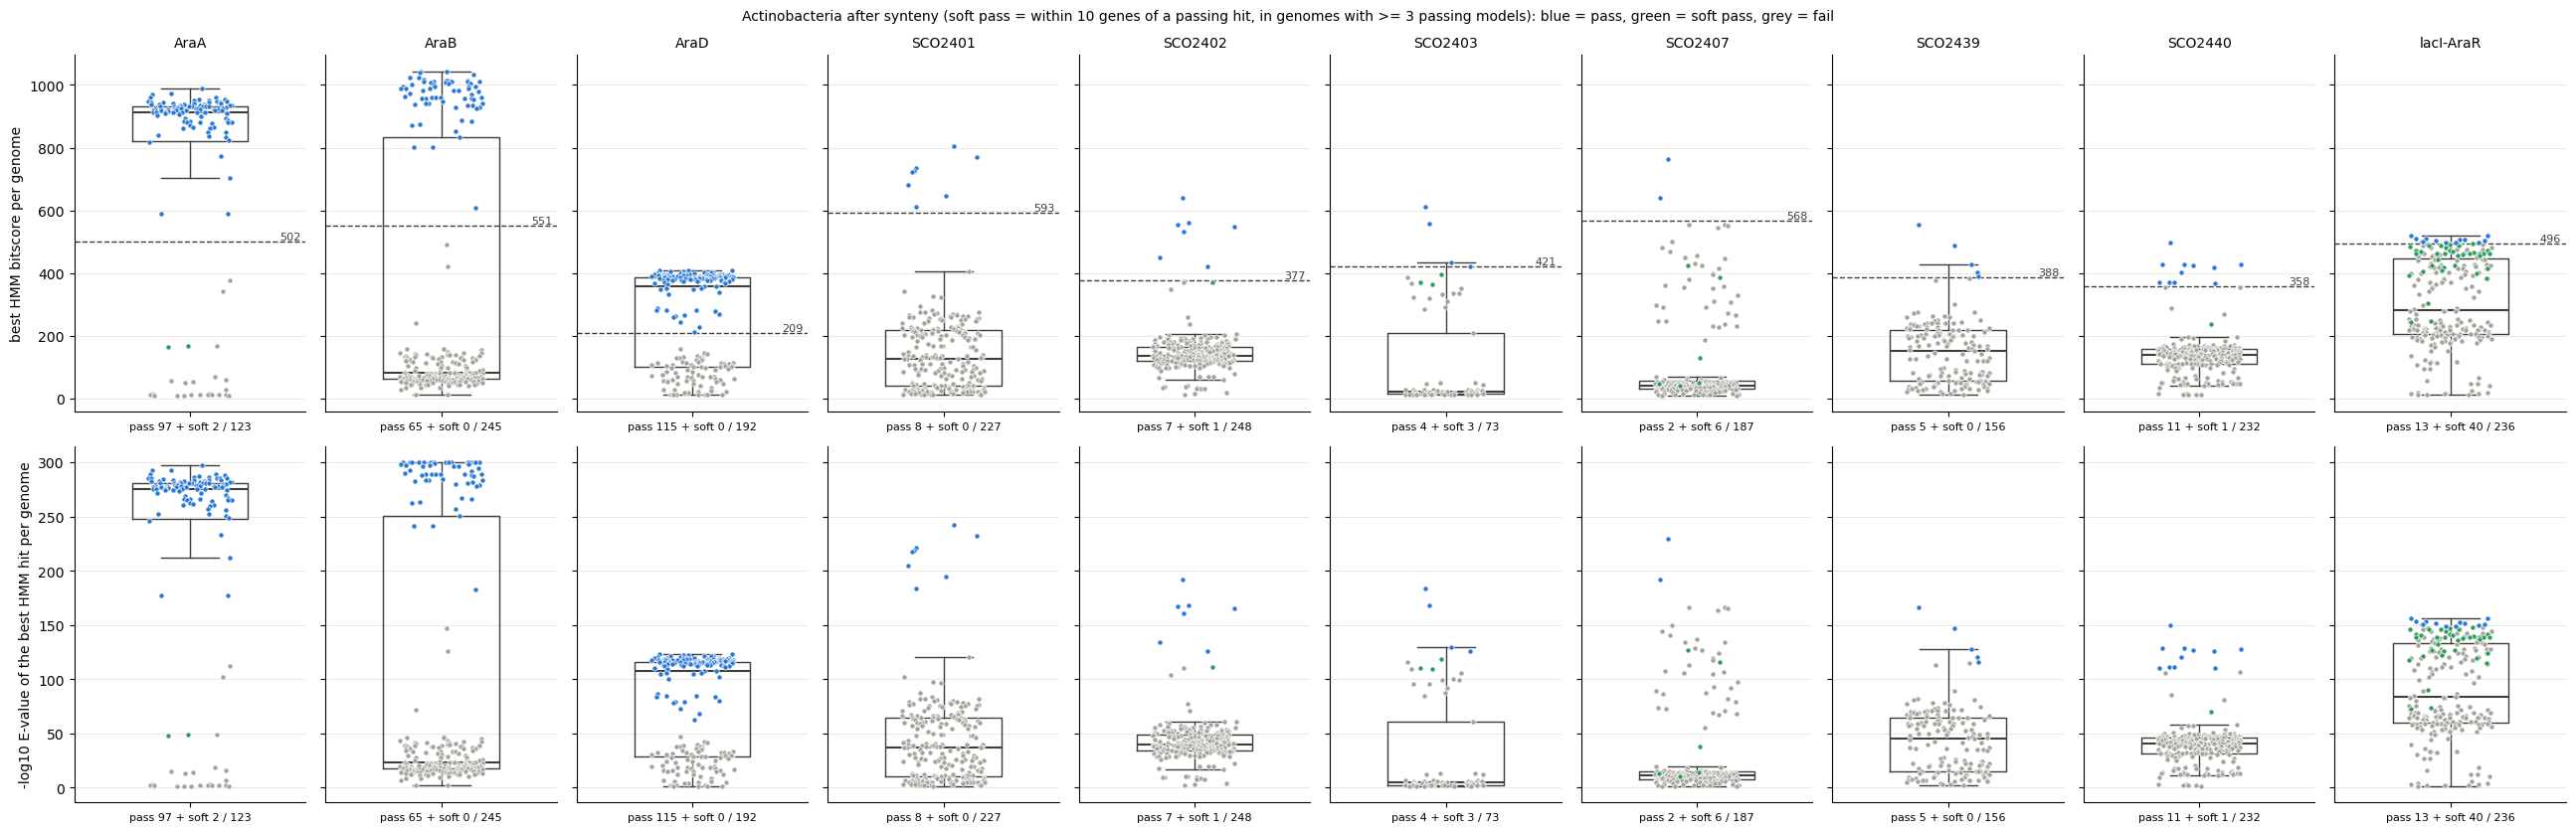

In [17]:
# best hit per (genome, model) in the Actinobacteria set after the synteny check:
# blue = passes the bitscore threshold, green = soft pass (near a passing hit), grey = fail
C_SOFT = "#2e9e5b"
STATUS_COLORS = [("fail", C_FAIL), ("Soft_pass", C_SOFT), ("pass", C_PASS)]  # drawn in this order

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, len(models), figsize=(2.6 * len(models), 8.5), sharey="row")

for col, model in enumerate(models):
    sub = actino_top[actino_top.model == model]
    jitter = pd.Series(rng.uniform(-0.18, 0.18, len(sub)), index=sub.index)
    log_e = -np.log10(sub.evalue.clip(lower=MIN_EVALUE))
    n_pass = (sub.status == "pass").sum()
    n_soft = (sub.status == "Soft_pass").sum()

    for ax, values in [(axes[0, col], sub.bitscore), (axes[1, col], log_e)]:
        ax.boxplot(values, positions=[0], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        for status, color in STATUS_COLORS:
            is_status = sub.status == status
            ax.scatter(jitter[is_status], values[is_status], s=14, color=color,
                       edgecolor="white", linewidth=0.5, zorder=3)
        ax.set_xticks([0], [f"pass {n_pass} + soft {n_soft} / {len(sub)}"], fontsize=8)
        ax.set_xlim(-0.5, 0.5)
        ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)

    threshold = thresholds.loc[model, "threshold"]
    axes[0, col].axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    axes[0, col].text(0.48, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    axes[0, col].set_title(model, fontsize=10)

axes[0, 0].set_ylabel("best HMM bitscore per genome")
axes[1, 0].set_ylabel("-log10 E-value of the best HMM hit per genome")
fig.suptitle(f"Actinobacteria after synteny (soft pass = within {SOFT_PASS_N} genes of a passing hit, "
             f"in genomes with >= {MIN_PASSING_GENES} passing models): "
             "blue = pass, green = soft pass, grey = fail", fontsize=10)
fig.tight_layout()
plt.show()

In [ ]:
# Export the Actinobacteria hits before synteny check, for downstream analysis

actino_top.to_csv(HMM_DIR / "results" / "actino_top_hits_after_synteny.tsv", sep="\t", index=False)

In [ ]:
# Export the Streptomycetae hits for downstream analysis: best hit per (genome, model) against the same
# per-model thresholds as the Actinobacteria set. No synteny soft passes for this set, so status is pass or fail.
strep_top = hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 1)].copy()
strep_top["threshold"] = strep_top.model.map(thresholds.threshold)
strep_top = strep_top[strep_top.threshold.notna()]
strep_top["passes"] = strep_top.bitscore >= strep_top.threshold
strep_top["status"] = strep_top.passes.map({True: "pass", False: "fail"})

strep_top.to_csv(HMM_DIR / "results" / "strep_top_hits.tsv", sep="\t", index=False)
print(f"{len(strep_top)} best hits from {strep_top.tblout.nunique()} genomes, {strep_top.passes.sum()} pass")

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# rows follow the order tree; colour = fraction of the genomes in each order with a passing hit,
# the genome count is written in each cell
fractions = contingency.loc[order_rows, gene_columns].div(contingency.loc[order_rows, "n_genomes"], axis=0)

# one hue, light -> dark: 0 sits close to the background, 1 is the darkest blue
CMAP = LinearSegmentedColormap.from_list(
    "fraction", ["#f4f3f0", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"]
)
INK = "#3d3d3a"       # text on light cells
INK_MUTED = "#73726c"
PATHWAY_GAP = 0.5     # blank space between the vnz/Ara and the SCO columns

# x position of each gene column, with the gap after the last vnz/Ara gene
n_ara = len(PATHWAYS["vnz/Ara"])
x_pos = [i + (PATHWAY_GAP if i >= n_ara else 0) for i in range(len(gene_columns))]


def cladogram_coords(tree):
    """x = node depth (tips aligned on the right), y = row centre of each clade."""
    x, y = {}, {}

    def set_x(clade, depth):
        x[clade] = depth
        for child in clade.clades:
            set_x(child, depth + 1)

    set_x(tree.root, 0)
    max_depth = max(x.values())
    for row, tip in enumerate(tree.get_terminals()):
        x[tip] = max_depth
        y[tip] = row + 0.5

    def set_y(clade):
        if not clade.is_terminal():
            child_y = [set_y(child) for child in clade.clades]
            y[clade] = (min(child_y) + max(child_y)) / 2
        return y[clade]

    set_y(tree.root)
    return x, y


fig, (tree_ax, ax) = plt.subplots(
    1, 2, figsize=(0.7 * len(gene_columns) + 5.5, 0.42 * len(order_rows) + 1.6),
    gridspec_kw={"width_ratios": [1.3, 0.7 * len(gene_columns)]},
)
    gridspec_kw={"width_ratios": [1.3, 0.7 * len(gene_columns)]},
)

# order tree (topology only; branch lengths not drawn)
x, y = cladogram_coords(tree)
for clade in tree.find_clades(order="preorder"):
    if clade.is_terminal():
        continue
    child_y = [y[child] for child in clade.clades]
    tree_ax.plot([x[clade], x[clade]], [min(child_y), max(child_y)], color=INK, linewidth=1.2)
    for child in clade.clades:
        tree_ax.plot([x[clade], x[child]], [y[child], y[child]], color=INK, linewidth=1.2)
tree_ax.set_ylim(len(order_rows), 0)
tree_ax.set_xlim(-0.2, max(x.values()) + 0.1)
tree_ax.axis("off")

# heatmap
for row, order in enumerate(order_rows):
    for col, gene in enumerate(gene_columns):
        value = fractions.loc[order, gene]
        ax.add_patch(plt.Rectangle((x_pos[col], row), 1, 1, facecolor=CMAP(value),
                                   edgecolor="white", linewidth=2))
        ax.text(x_pos[col] + 0.5, row + 0.5, contingency.loc[order, gene], ha="center", va="center",
                fontsize=8, color="white" if value > 0.5 else INK)

ax.set_xlim(0, x_pos[-1] + 1)
ax.set_ylim(len(order_rows), 0)
ax.set_xticks([x_ + 0.5 for x_ in x_pos], gene_columns, rotation=45, ha="right", fontsize=9, color=INK)
# * = the order is not one clade in the tree
ax.set_yticks([r + 0.5 for r in range(len(order_rows))],
              [f"{order}{'*' if order in not_monophyletic else ''} (n={contingency.loc[order, 'n_genomes']})"
               for order in order_rows], fontsize=9, color=INK)
ax.tick_params(length=0)
for side in ax.spines.values():
    side.set_visible(False)

# pathway names above their column blocks
for pathway, start, end in [("vnz/Ara", 0, n_ara), ("SCO", n_ara, len(gene_columns))]:
    middle = (x_pos[start] + x_pos[end - 1] + 1) / 2
    ax.text(middle, -0.35, pathway, ha="center", va="bottom", fontsize=10, color=INK, fontweight="bold")

colorbar = fig.colorbar(ScalarMappable(cmap=CMAP), ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("fraction of genomes with a passing hit", fontsize=8, color=INK_MUTED)
colorbar.ax.tick_params(labelsize=8, colors=INK_MUTED, length=0)
colorbar.outline.set_visible(False)

if not_monophyletic:
    fig.text(0.01, 0.01, "* not one clade in the tree; midpoint-rooted tree without outgroup (temporary)",
             fontsize=7, color=INK_MUTED)

fig.tight_layout()
plt.show()

IndentationError: unexpected indent (1919167428.py, line 51)